# Training Log Preprocessing

This notebook processes training log files with the following stages:
1. Remove metadata and parse to dataframe
2. **Validate** timestamp order (ensure raw data is roughly chronological)
3. Remove overlapped data from interrupted sessions (Issue 1)
4. **Validate** timestamp order again (ensure cleaning resulted in a strictly monotonic timeline)
5. Preprocess timestamps, expand to full 100k iteration range
6. **Estimate** missing time data using robust signal statistics (median valid speed) instead of linear regression
7. Create analytical plots

In [53]:
import re
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

%matplotlib inline
%load_ext autoreload
%autoreload 2
from preprocess_train_logs import *


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## Configuration

In [54]:
INPUT_FILE = r"G:\My Drive\Biometrics\HSTL-utils\p3d-circleloss-log\logs\output\CASIA-B\HSTL\p3d-circleloss\summary\manual_train_log.txt"
# '''
# G:\My Drive\Biometrics\HSTL-utils\origin-log\logs\kaggle\output\CASIA-B\HSTL\kaggle\summary\manual_train_log.txt
# G:\My Drive\Biometrics\HSTL-utils\P3D-log\output_local\output\CASIA-B\HSTL\p3d\summary\manual_train_log.txt
# G:\My Drive\Biometrics\HSTL-utils\circleloss-log\logs\medium\output\CASIA-B\HSTL\med-circleloss\summary\manual_train_log.txt
# G:\My Drive\Biometrics\HSTL-utils\p3d-circleloss-log\logs\output\CASIA-B\HSTL\p3d-circleloss\summary\manual_train_log.txt
# '''

> **Note**: Helper functions are imported from `preprocess_train_logs.py`.

## Stage 1: Load and Parse Data

In [55]:
input_path = Path(INPUT_FILE)

with open(input_path, 'r', encoding='utf-8') as f:
    content = f.read()

print(f"File loaded: {input_path}")

File loaded: G:\My Drive\Biometrics\HSTL-utils\p3d-circleloss-log\logs\output\CASIA-B\HSTL\p3d-circleloss\summary\manual_train_log.txt


In [56]:
print("Removing metadata...")
clean_lines = remove_metadata(content)
print(f"Clean lines: {len(clean_lines)}")

Removing metadata...
Clean lines: 342


In [57]:
print("Parsing to dataframe...")
df = parse_logs_to_dataframe(clean_lines)
print(f"Shape: {df.shape}")
print(f"Columns: {list(df.columns)}")
df.head(10)

Parsing to dataframe...
Shape: (335, 6)
Columns: ['timestamp', 'iterations', 'cost', 'circle_loss', 'softmax_loss', 'softmax_accuracy']


,timestamp,iterations,cost,circle_loss,softmax_loss,softmax_accuracy
0,2025-12-29 04:32:27,300,637.06,84.3125,4.3051,0.0172
1,2025-12-29 04:42:27,600,600.09,78.4375,4.2683,0.0281
2,2025-12-29 04:52:25,900,598.58,76.6250,4.2186,0.0442
3,2025-12-29 05:02:22,1200,597.19,75.5625,4.1470,0.0599
4,2025-12-29 05:12:20,1500,597.97,74.8125,4.0598,0.0821
5,2025-12-29 05:22:20,1800,599.58,74.5000,3.9728,0.1035
6,2025-12-29 05:32:22,2100,602.25,73.8750,3.8690,0.1348
7,2025-12-29 05:42:23,2400,600.38,73.6250,3.7639,0.1632
8,2025-12-29 05:54:26,2700,395.26,73.2500,3.6447,0.1993
9,2025-12-29 06:04:18,3000,592.84,73.1875,3.5349,0.2262


In [58]:
print("Validating timestamp order before processing...")
try:
    validate_timestamp_order(df, "Stage 1: Raw Data")
except ValueError as e:
    print(f"VALIDATION FAILED: {e}")
    # We proceed but note the error

Validating timestamp order before processing...
Timestamp validation passed for 'Stage 1: Raw Data'.


## Stage 1.5: Remove Overlapped/Duplicated Sessions (Issue 1)

In [59]:
print("Removing overlapped sessions...")
df_clean = remove_overlapped_data(df)
print(f"Original size: {len(df)}")
print(f"Cleaned size: {len(df_clean)}")
print(f"Removed records: {len(df) - len(df_clean)}")

print("\nValidating timestamp order AFTER removing overlapped data...")
try:
    validate_timestamp_order(df_clean, "Stage 1.5: After Overlap Removal")
except ValueError as e:
    print(f"VALIDATION FAILED: {e}")

output_stage1 = input_path.parent / f"{input_path.stem}_preprocessed_stage1.csv"
df_clean.to_csv(output_stage1, index=False, float_format='%.15g')
print(f"Stage 1 output saved to {output_stage1}")

# # Check the cleaned data around the known overlap area (iter ~20600-22100)
# overlap_check = df_clean[(df_clean['iterations'] >= 20000) & (df_clean['iterations'] <= 22100)]
# overlap_check.head(20)

Removing overlapped sessions...
Original size: 335
Cleaned size: 334
Removed records: 1

Validating timestamp order AFTER removing overlapped data...
Timestamp validation passed for 'Stage 1.5: After Overlap Removal'.
Stage 1 output saved to G:\My Drive\Biometrics\HSTL-utils\p3d-circleloss-log\logs\output\CASIA-B\HSTL\p3d-circleloss\summary\manual_train_log_preprocessed_stage1.csv


## Stage 2: Preprocess Timestamps, Expand to Full Range, and Clean Data

In [60]:
# print("Preprocessing timestamps, expanding range, and estimating missing data...")
# df = preprocess_timestamps(df_clean)
# df[['iterations', 'time_from_prev', 'time_from_prev_estimated', 'time_from_prev_filled']].head(20)

In [61]:
# expand data records to default range 0 to 100K
df = expand_to_default_full_range(df_clean)
df.head(5)

add Iterations: 0


,timestamp,iterations,cost,circle_loss,softmax_loss,softmax_accuracy
0,NaT,0,NaN,NaN,NaN,NaN
1,2025-12-29 04:32:27,300,637.06,84.3125,4.3051,0.0172
2,2025-12-29 04:42:27,600,600.09,78.4375,4.2683,0.0281
3,2025-12-29 04:52:25,900,598.58,76.6250,4.2186,0.0442
4,2025-12-29 05:02:22,1200,597.19,75.5625,4.1470,0.0599


In [62]:
df.tail(5)

,timestamp,iterations,cost,circle_loss,softmax_loss,softmax_accuracy
330,2026-01-03 12:05:44,99000,584.38,41.6250,0.2904,0.9604
331,2026-01-03 12:15:30,99300,585.23,41.3125,0.2882,0.9613
332,2026-01-03 12:25:19,99600,589.05,41.5625,0.2918,0.9602
333,2026-01-03 12:35:04,99900,585.19,41.4688,0.2920,0.9604
334,2026-01-03 12:38:19,100000,587.19,41.5688,0.2922,0.9600


In [63]:
final_df = add_cum_cost(df)
final_df.head()

,timestamp,iterations,cost,circle_loss,softmax_loss,softmax_accuracy,cum_cost
0,NaT,0,NaN,NaN,NaN,NaN,0.00
1,2025-12-29 04:32:27,300,637.06,84.3125,4.3051,0.0172,637.06
2,2025-12-29 04:42:27,600,600.09,78.4375,4.2683,0.0281,1237.15
3,2025-12-29 04:52:25,900,598.58,76.6250,4.2186,0.0442,1835.73
4,2025-12-29 05:02:22,1200,597.19,75.5625,4.1470,0.0599,2432.92


In [64]:
final_df.tail()

,timestamp,iterations,cost,circle_loss,softmax_loss,softmax_accuracy,cum_cost
330,2026-01-03 12:05:44,99000,584.38,41.6250,0.2904,0.9604,187188.28
331,2026-01-03 12:15:30,99300,585.23,41.3125,0.2882,0.9613,187773.51
332,2026-01-03 12:25:19,99600,589.05,41.5625,0.2918,0.9602,188362.56
333,2026-01-03 12:35:04,99900,585.19,41.4688,0.2920,0.9604,188947.75
334,2026-01-03 12:38:19,100000,587.19,41.5688,0.2922,0.9600,189534.94


In [65]:
output_stage2 = input_path.parent / f"{input_path.stem}_preprocessed_stage2.csv"
final_df.to_csv(output_stage2, index=False, float_format='%.15g')
print(f"Stage 2 output saved to {output_stage2}")

Stage 2 output saved to G:\My Drive\Biometrics\HSTL-utils\p3d-circleloss-log\logs\output\CASIA-B\HSTL\p3d-circleloss\summary\manual_train_log_preprocessed_stage2.csv


## Stage 3: Analytics and Visualization

Creating plots...


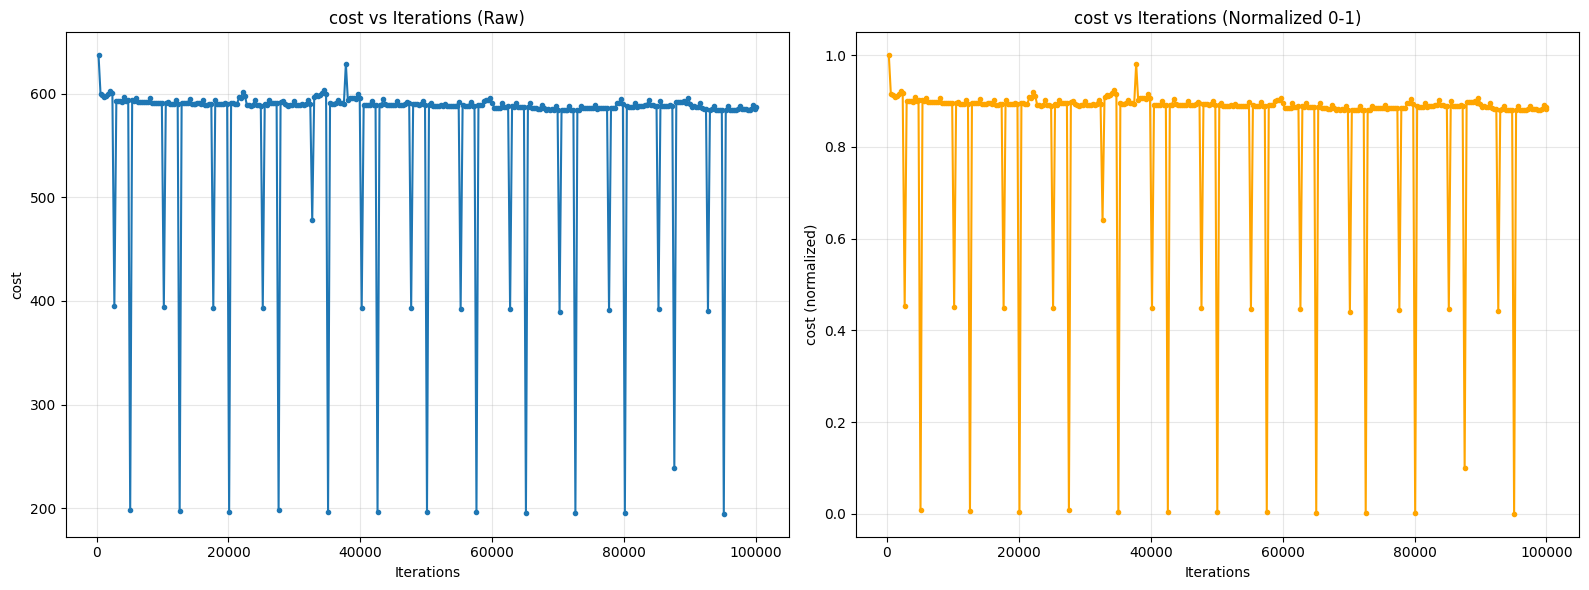

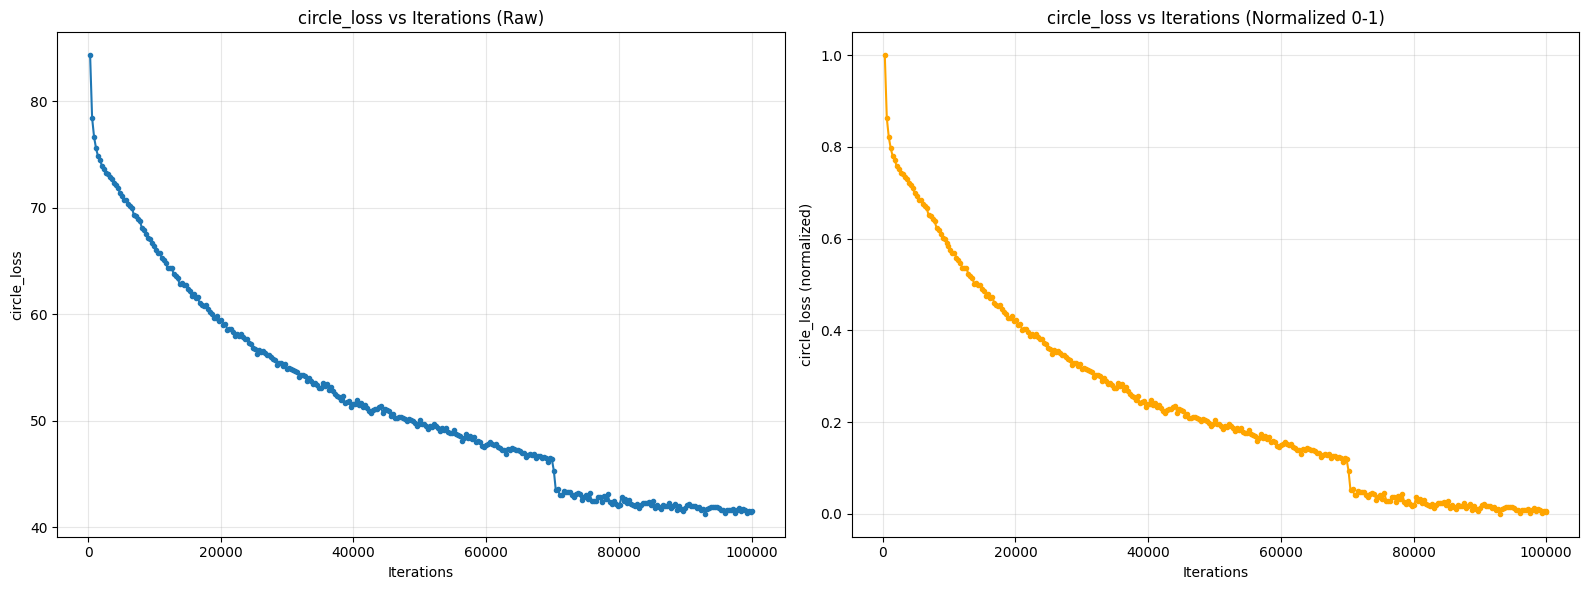

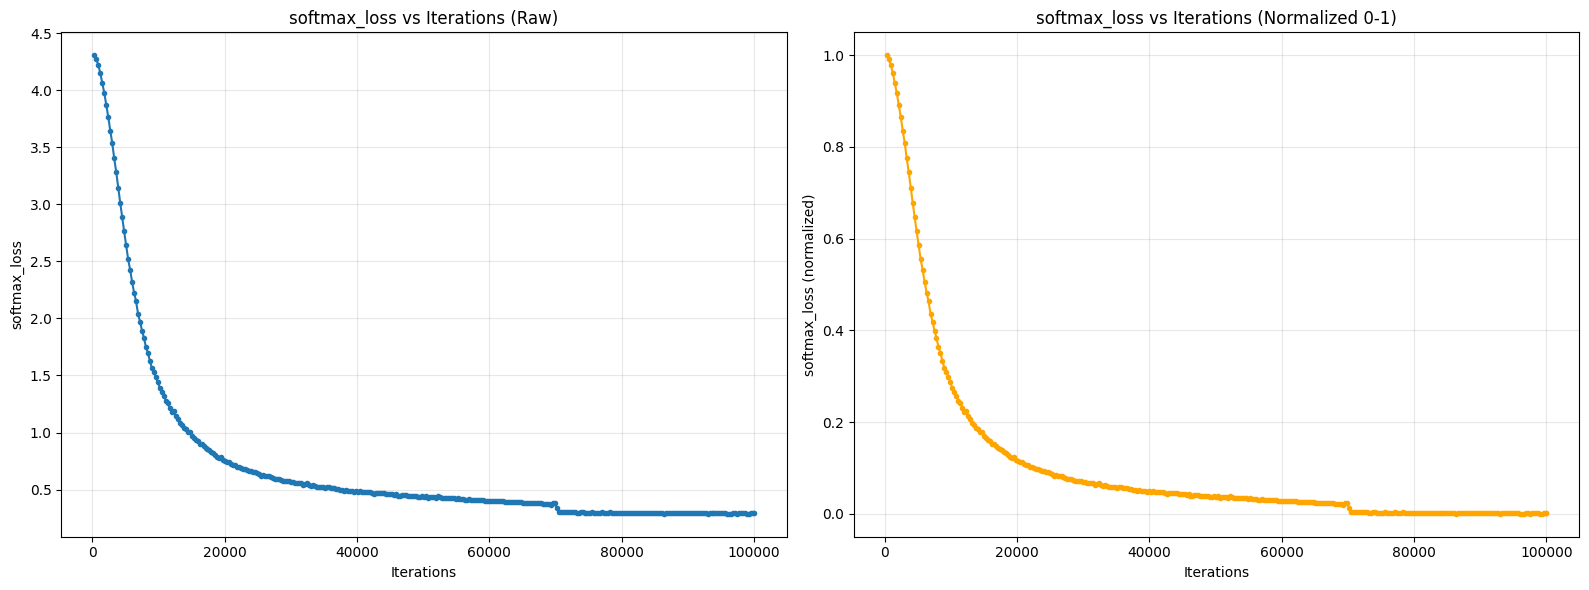

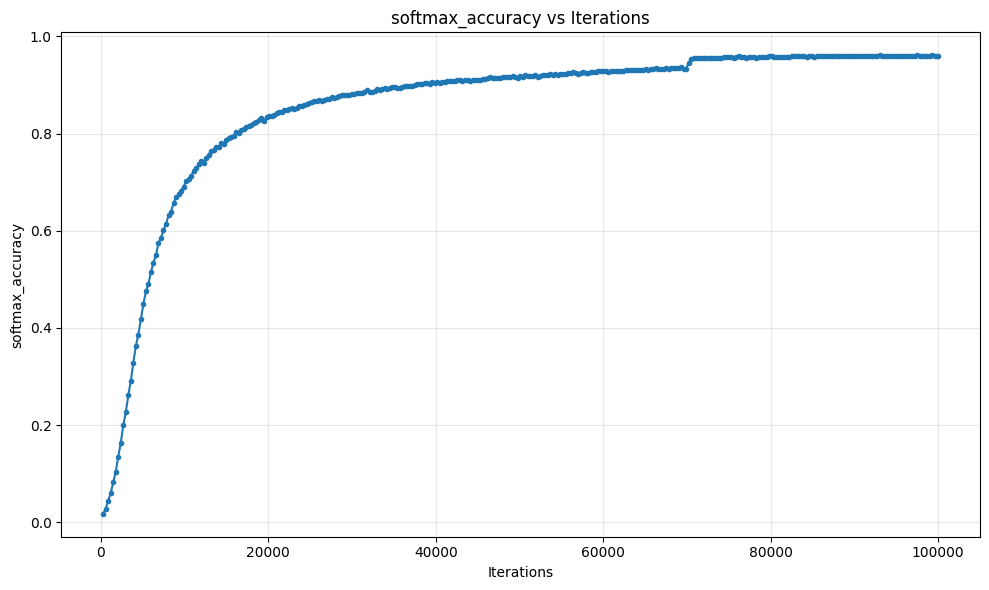

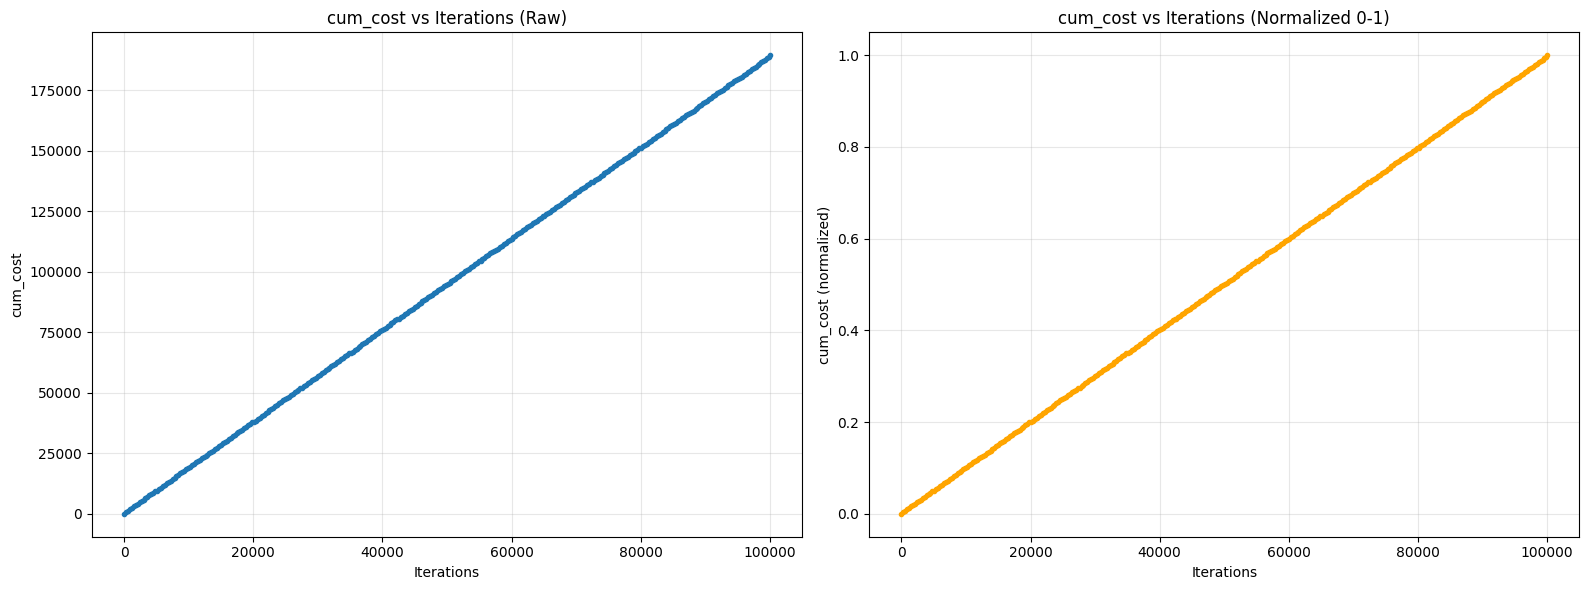

Plots saved to G:\My Drive\Biometrics\HSTL-utils\p3d-circleloss-log\logs\output\CASIA-B\HSTL\p3d-circleloss\summary\imgs


In [66]:
print("Creating plots...")
imgs_dir = input_path.parent / "imgs"
create_plots(final_df, str(imgs_dir))

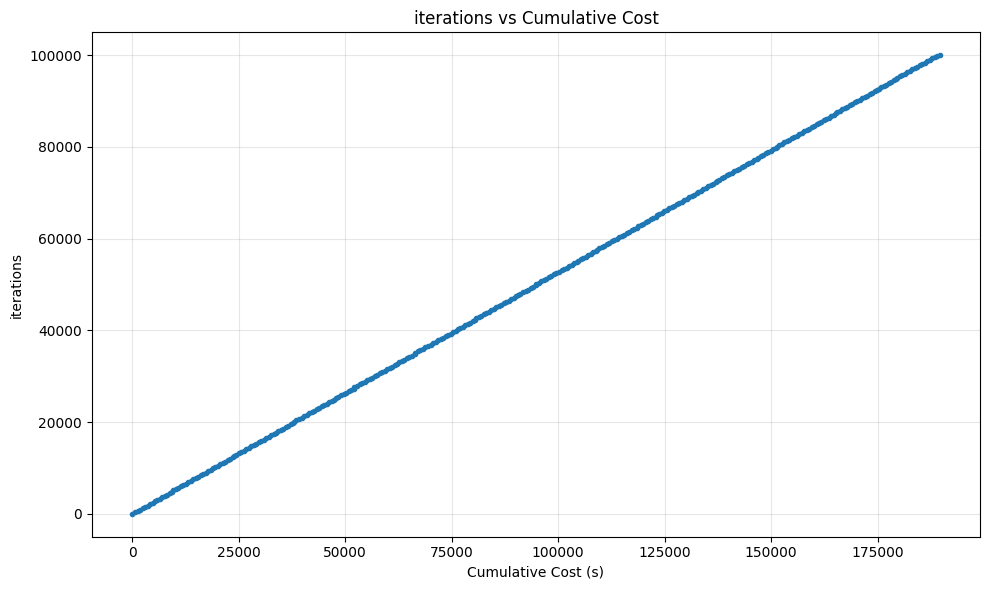

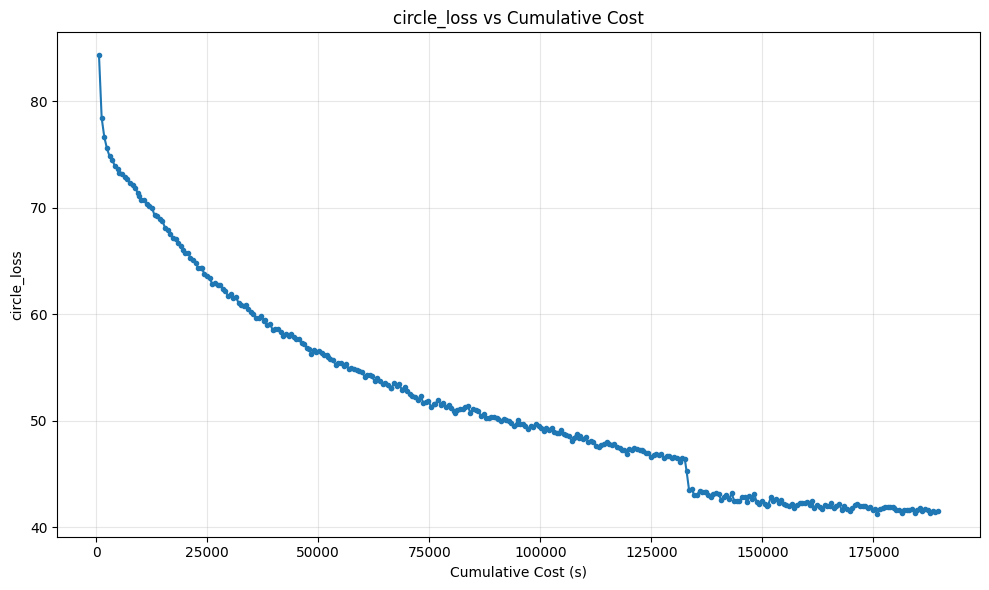

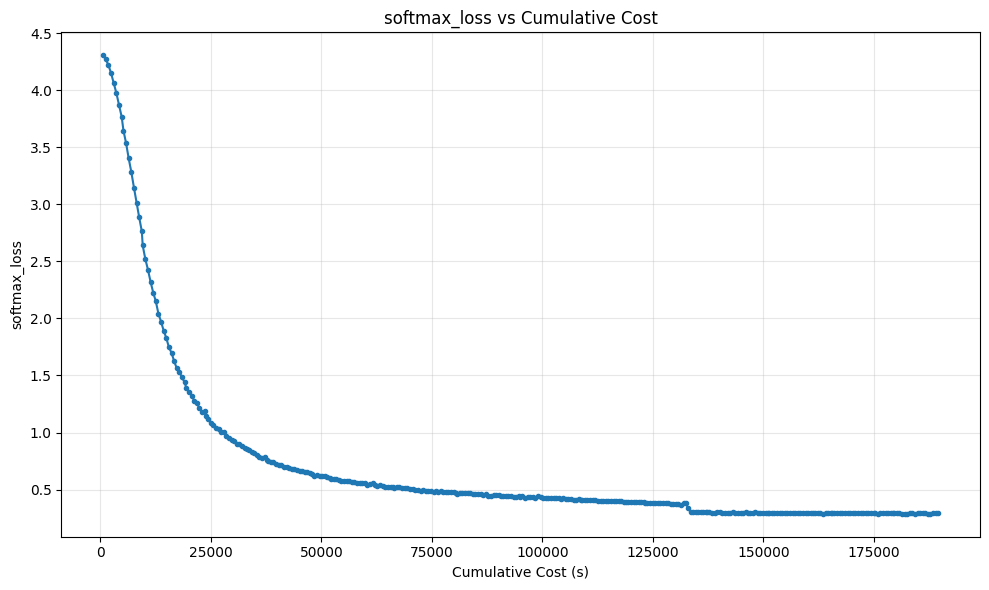

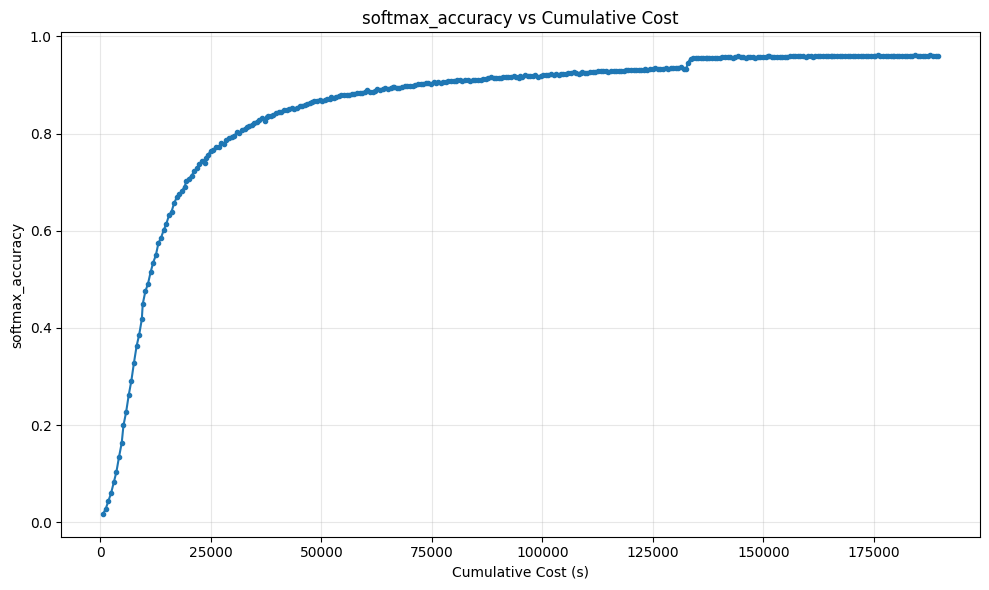

Time-based plots saved to G:\My Drive\Biometrics\HSTL-utils\p3d-circleloss-log\logs\output\CASIA-B\HSTL\p3d-circleloss\summary\imgs_time


In [67]:
time_imgs_dir = input_path.parent / "imgs_time"
create_plots_over_time(final_df, str(time_imgs_dir))

## Summary Statistics

In [68]:
print("Summary Statistics:")
df.describe()

Summary Statistics:


,timestamp,iterations,cost,circle_loss,softmax_loss,softmax_accuracy
count,334,335.000000,334.000000,334.000000,334.000000,334.000000
mean,2025-12-31 10:34:41.769460992,50099.402985,567.469880,51.726254,0.706569,0.858467
min,2025-12-29 04:32:27,0.000000,194.620000,41.281200,0.288200,0.017200
25%,2025-12-29 20:03:52.500000,25050.000000,586.527500,42.867225,0.299075,0.865225
50%,2025-12-30 12:43:32.500000,50100.000000,589.020000,49.703150,0.438900,0.917750
75%,2026-01-02 03:39:49.249999872,75150.000000,591.347500,56.749950,0.632725,0.956825
max,2026-01-03 12:38:19,100000.000000,637.060000,84.312500,4.305100,0.961300
std,NaN,29054.089547,83.144489,9.283441,0.776920,0.176611


In [69]:
print("\nData Info:")
df.info()


Data Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 335 entries, 0 to 334
Data columns (total 6 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   timestamp         334 non-null    datetime64[ns]
 1   iterations        335 non-null    int64         
 2   cost              334 non-null    float64       
 3   circle_loss       334 non-null    float64       
 4   softmax_loss      334 non-null    float64       
 5   softmax_accuracy  334 non-null    float64       
dtypes: datetime64[ns](1), float64(4), int64(1)
memory usage: 15.8 KB
